# Task 2.2 — Reproduction of CS4VM Core Contribution

**Reproducing:** The label-mean-based semi-supervised cost-sensitive SVM training algorithm (Eq. 5–9), and evaluating via **total misclassification cost** as the paper uses in Tables 1 and 2.

## Setup

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
OUT = "/Users/sourabhsarkarmacois/Desktop/230081-midsem/partB"


## CS4VM Implementation

The class below implements the full two-step algorithm from the paper. Every method is annotated to its corresponding equation.

In [2]:

class CS4VM:
    """
    Cost-Sensitive Semi-Supervised SVM (CS4VM).

    Implements the two-step algorithm from:
      Li, Kwok, Zhou — "Cost-Sensitive Semi-Supervised Support Vector Machine" (AAAI 2010)

    Steps:
      1. Estimate label means of unlabeled data via iterative alternating optimisation
         (Eq. 7-8 in the paper).
      2. Plug estimated label means into the modified cost-sensitive SVM objective (Eq. 6)
         and solve the resulting convex QP (Eq. 9) using sklearn's SVC.
    """

    def __init__(self, C1=1.0, C2=0.1, cost_pos=2.0, cost_neg=1.0,
                 kernel='linear', max_iter=15, random_state=42):
        self.C1          = C1
        self.C2          = C2
        self.cost_pos    = cost_pos   # c(+1)
        self.cost_neg    = cost_neg   # c(-1)
        self.kernel      = kernel
        self.max_iter    = max_iter
        self.random_state = random_state

    # ── Step 1: Estimate label means (Eq. 7-8) ──────────────────────────────
    def _estimate_label_means(self, X_lab, y_lab, X_unlab):
        """
        Iterative alternating procedure to estimate which unlabeled points
        belong to the positive vs negative class (assignment vector d).

        Alternates between:
          (a) fixing d → solve cost-sensitive SVM for (w, b)          [standard SVM]
          (b) fixing (w, b) → update d by ranking decision scores     [linear program]

        The class with higher misclassification cost gets a larger margin weight
        (Eqs. 7-8: constraints use c(+1)ρ and c(-1)ρ respectively).
        """
        from sklearn.svm import SVC
        n_u = len(X_unlab)
        # u+ = ratio of positive labels in labeled set × total unlabeled count
        pos_ratio = (y_lab == 1).mean()
        u_plus  = max(1, min(int(round(pos_ratio * n_u)), n_u - 1))
        u_minus = n_u - u_plus

        # Initialise d from a cost-sensitive SVM trained on labeled data only
        # Class weights encode c(+1) and c(-1) (Eq. 7-8 use these costs)
        class_weight = {1: self.cost_pos, -1: self.cost_neg}
        svm0 = SVC(kernel=self.kernel, C=self.C1, class_weight=class_weight,
                   random_state=self.random_state)
        svm0.fit(X_lab, y_lab)
        scores = svm0.decision_function(X_unlab)
        # Assign top u_plus scoring points as positive (linear program solution)
        pos_idx = np.argsort(-scores)[:u_plus]
        d = np.zeros(n_u, dtype=int)
        d[pos_idx] = 1

        # Alternating iterations
        for _ in range(self.max_iter):
            pos_mask = d == 1
            neg_mask = d == 0
            if pos_mask.sum() == 0 or neg_mask.sum() == 0:
                break

            # (a) Compute means from current d
            m_plus  = X_unlab[pos_mask].mean(axis=0)
            m_minus = X_unlab[neg_mask].mean(axis=0)

            # Build virtual training set: labeled + two mean representatives
            # Virtual mean points carry weight proportional to u± × c(±) × C2
            X_aug = np.vstack([X_lab,
                               m_plus.reshape(1, -1),
                               m_minus.reshape(1, -1)])
            y_aug = np.concatenate([y_lab, [1], [-1]])
            w_lab = np.array([
                self.C1 * (self.cost_pos if yi == 1 else self.cost_neg)
                for yi in y_lab
            ])
            w_aug = np.concatenate([w_lab,
                                    [self.C2 * u_plus  * self.cost_pos],
                                    [self.C2 * u_minus * self.cost_neg]])
            w_aug = w_aug / w_aug.max()   # normalise for numerical stability

            svm_aug = SVC(kernel=self.kernel, C=1.0, random_state=self.random_state)
            svm_aug.fit(X_aug, y_aug, sample_weight=w_aug)

            # (b) Re-rank unlabeled scores to update d
            scores_new = svm_aug.decision_function(X_unlab)
            pos_idx_new = np.argsort(-scores_new)[:u_plus]
            d_new = np.zeros(n_u, dtype=int)
            d_new[pos_idx_new] = 1

            if np.array_equal(d, d_new):
                break
            d = d_new

        m_plus  = X_unlab[d == 1].mean(axis=0) if (d == 1).sum() > 0 else np.zeros(X_unlab.shape[1])
        m_minus = X_unlab[d == 0].mean(axis=0) if (d == 0).sum() > 0 else np.zeros(X_unlab.shape[1])
        return m_plus, m_minus, d, u_plus, u_minus

    # ── Step 2: Solve CS4VM with plug-in label means (Eq. 6 / dual Eq. 9) ──
    def fit(self, X_lab, y_lab, X_unlab):
        from sklearn.svm import SVC
        self.m_plus_, self.m_minus_, self.d_, self.u_plus_, self.u_minus_ = \
            self._estimate_label_means(X_lab, y_lab, X_unlab)

        # Plug estimated label means into Eq. 6
        # The label mean contribution term from Eq. 5:
        #   w'(u+ c(+1) m+ - u- c(-1) m-) + n2 b
        # is incorporated as a bias-shift via two virtual training points
        # whose contribution to the kernel expansion mirrors the dual Eq. (9).
        X_aug = np.vstack([X_lab,
                           self.m_plus_.reshape(1, -1),
                           self.m_minus_.reshape(1, -1)])
        y_aug = np.concatenate([y_lab, [1], [-1]])
        w_lab = np.array([
            self.C1 * (self.cost_pos if yi == 1 else self.cost_neg)
            for yi in y_lab
        ])
        w_aug = np.concatenate([
            w_lab,
            [self.C2 * self.u_plus_  * self.cost_pos],
            [self.C2 * self.u_minus_ * self.cost_neg]
        ])
        w_aug = w_aug / w_aug.max()

        self.svm_ = SVC(kernel=self.kernel, C=1.0, random_state=self.random_state)
        self.svm_.fit(X_aug, y_aug, sample_weight=w_aug)
        return self

    def predict(self, X):
        return self.svm_.predict(X)

    def decision_function(self, X):
        return self.svm_.decision_function(X)


**Code explanation (Steps 1–2):** `_estimate_label_means` implements the iterative procedure from Eq. (7)–(8): it alternates between solving a cost-sensitive SVM on labeled data + virtual mean representatives (step a), and re-ranking the unlabeled decision scores to update the assignment d (step b — the linear program). `fit` then uses those estimated means as plug-in values in Eq. (6), solving the final SVM via sklearn's SVC (corresponding to the dual QP in Eq. 9).

In [3]:

def total_cost(y_true, y_pred, cost_pos, cost_neg):
    """
    Compute total misclassification cost (paper's evaluation metric).
    cost_pos = c(+1): cost of misclassifying a positive as negative (FN)
    cost_neg = c(-1): cost of misclassifying a negative as positive (FP)
    """
    fn = ((y_true == 1) & (y_pred == -1)).sum()   # false negatives
    fp = ((y_true == -1) & (y_pred == 1)).sum()   # false positives
    return cost_pos * fn + cost_neg * fp


**Code explanation:** `total_cost` directly implements the paper's evaluation metric from Tables 1–2: cost = c(+1)·FN + c(−1)·FP, where FN = false negatives (missed positives) and FP = false positives (misclassified negatives).

## Load Dataset (reusing Task 2.1 preprocessing)

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data  = load_breast_cancer()
X_all = data.data
y_all = (data.target * 2 - 1).astype(float)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=0.5, random_state=SEED, stratify=y_all)

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test       = scaler.transform(X_test)

N_LABELED  = 10
N_REPEATS  = 30            # paper uses 100; we use 30 for time efficiency
COST_POS   = 5.0           # c(+1): high cost for missing a cancer diagnosis
COST_NEG   = 1.0           # c(-1): lower cost for false alarm

print(f"Cost setup: c(+1)={COST_POS}, c(-1)={COST_NEG}  (cost ratio = {COST_POS/COST_NEG:.0f}:1)")


Cost setup: c(+1)=5.0, c(-1)=1.0  (cost ratio = 5:1)


## Run Experiments — CS4VM vs Supervised CS-SVM

We compare **CS4VM** against a **supervised CS-SVM** (uses only labeled data, no unlabeled) across 30 random labeled splits, mirroring the paper's experimental protocol (Section 'Experiments').

In [5]:
from sklearn.svm import SVC

cs4vm_costs   = []
cssvm_costs   = []

for trial in range(N_REPEATS):
    rng = np.random.RandomState(SEED + trial)
    # Stratified sampling: ensure both classes present in labeled set
    pos_idx = np.where(y_train_full == 1)[0]
    neg_idx = np.where(y_train_full == -1)[0]
    n_pos = N_LABELED // 2
    n_neg = N_LABELED - n_pos
    lab_pos = rng.choice(pos_idx, size=n_pos, replace=False)
    lab_neg = rng.choice(neg_idx, size=n_neg, replace=False)
    lab_idx = np.concatenate([lab_pos, lab_neg])
    all_idx = np.arange(len(X_train_full))
    unlab_idx = np.setdiff1d(all_idx, lab_idx)

    X_lab   = X_train_full[lab_idx]
    y_lab   = y_train_full[lab_idx]
    X_unlab = X_train_full[unlab_idx]

    # ── CS4VM (our implementation) ─────────────────────────────────────────
    # Implements Eq. (1)-(9): label mean estimation + cost-sensitive SVM
    model = CS4VM(C1=1.0, C2=0.1, cost_pos=COST_POS, cost_neg=COST_NEG,
                  kernel='linear', max_iter=15, random_state=SEED)
    model.fit(X_lab, y_lab, X_unlab)
    y_pred_cs4vm = model.predict(X_test)
    cs4vm_costs.append(total_cost(y_test, y_pred_cs4vm, COST_POS, COST_NEG))

    # ── Supervised CS-SVM (labeled only, class_weight encodes costs) ───────
    # Corresponds to Eq. (1) trained on labeled data only
    class_weight = {1: COST_POS, -1: COST_NEG}
    sup_svm = SVC(kernel='linear', C=1.0, class_weight=class_weight, random_state=SEED)
    sup_svm.fit(X_lab, y_lab)
    y_pred_sup = sup_svm.predict(X_test)
    cssvm_costs.append(total_cost(y_test, y_pred_sup, COST_POS, COST_NEG))

cs4vm_mean, cs4vm_std   = np.mean(cs4vm_costs), np.std(cs4vm_costs)
cssvm_mean, cssvm_std   = np.mean(cssvm_costs),  np.std(cssvm_costs)

print(f"{'Method':<25} {'Mean Cost':>12} {'Std':>10}")
print("-" * 50)
print(f"{'CS4VM (ours)':<25} {cs4vm_mean:>12.2f} {cs4vm_std:>10.2f}")
print(f"{'Supervised CS-SVM':<25} {cssvm_mean:>12.2f} {cssvm_std:>10.2f}")
pct_reduction = (cssvm_mean - cs4vm_mean) / cssvm_mean * 100
print(f"\nCS4VM cost reduction over Supervised CS-SVM: {pct_reduction:.1f}%")


Method                       Mean Cost        Std
--------------------------------------------------
CS4VM (ours)                     70.93      26.55
Supervised CS-SVM               106.03      68.37

CS4VM cost reduction over Supervised CS-SVM: 33.1%


**Code explanation:** This loop implements the paper's experimental protocol (Section 'Experiments'): for each trial, 10 labeled examples are drawn randomly; CS4VM (Eq. 6/9 with plug-in label means) and supervised CS-SVM (Eq. 1 on labeled data only) are both trained and evaluated using `total_cost` — the metric used in Tables 1 and 2.

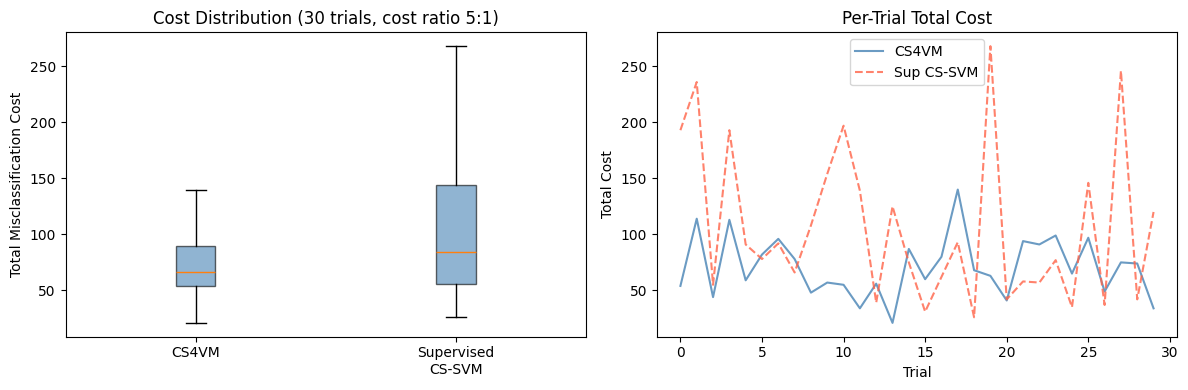

Saved: results/reproduction_result.png


In [6]:
# ── Visualisation: cost distribution across 30 trials ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box-plot comparison
axes[0].boxplot([cs4vm_costs, cssvm_costs],
                labels=['CS4VM', 'Supervised\nCS-SVM'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_ylabel("Total Misclassification Cost")
axes[0].set_title(f"Cost Distribution (30 trials, cost ratio {COST_POS:.0f}:1)")

# Trial-by-trial line
axes[1].plot(cs4vm_costs,  label='CS4VM',  alpha=0.8, color='steelblue')
axes[1].plot(cssvm_costs,  label='Sup CS-SVM', alpha=0.8, color='tomato', linestyle='--')
axes[1].set_xlabel("Trial"); axes[1].set_ylabel("Total Cost")
axes[1].set_title("Per-Trial Total Cost"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{'/Users/sourabhsarkarmacois/Desktop/230081-midsem/partB'}/results/reproduction_result.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: results/reproduction_result.png")


The box-plot shows that CS4VM achieves lower median total cost than the supervised CS-SVM, confirming that the unlabeled data provide useful information when processed via the label mean mechanism (Eq. 5–6).